In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries successfully imported!")

Libraries successfully imported!


In [62]:
df = pd.read_csv("C:\\Users\\IH Laptop\\Downloads\\covid-19-cases-in-pakistan-2020.csv")
df.head()

,Unnamed: 0,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours
0,4,48,2,80,3/11/2020,0,0,NaN,3,ICT,2,8
1,5,61,0,95,3/11/2020,0,0,NaN,6,Punjab,0,7
2,6,84,14,171,3/11/2020,1,0,NaN,1,Sindh,13,55
3,7,20,0,28,3/11/2020,0,0,NaN,0,KP,0,2
4,8,3,0,0,3/11/2020,0,0,NaN,0,KPTD,0,0


In [63]:
df.drop(columns=["Unnamed: 0"], errors='ignore', inplace=True)
print("Extra column dropped!")

Extra column dropped!


In [64]:
df.columns = [
    "Total_Cases", "Cumulative_Positive", "Cumulative_Tests", "Date", 
    "Recovered", "Deaths", "Home_Quarantine", "New_Cases", 
    "Region", "Active_Cases", "New_Tests"
]
print("Columns renamed successfully:\n", df.columns.tolist())

Columns renamed successfully:
 ['Total_Cases', 'Cumulative_Positive', 'Cumulative_Tests', 'Date', 'Recovered', 'Deaths', 'Home_Quarantine', 'New_Cases', 'Region', 'Active_Cases', 'New_Tests']


In [65]:
df['Home_Quarantine'] = df['Home_Quarantine'].fillna(0)
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df['New_Tests'] = df['New_Tests'].astype(str).str.replace('No 0', '0').str.strip()
df['New_Tests'] = pd.to_numeric(df['New_Tests'], errors='coerce').fillna(0).astype(int)
print("Missing values and data types fixed!")

Missing values and data types fixed!


In [66]:
df['Region'] = df['Region'].astype(str).str.strip()
df = df[df['Region'] != 'Mobile Lab']
region_mapping = {
    'KP': 'KPK',
    'KPTD': 'KPK'
}
df['Region'] = df['Region'].replace(region_mapping)
print("--- Final Cleaned Regions List ---")
print(df['Region'].unique())

--- Final Cleaned Regions List ---
['ICT' 'Punjab' 'Sindh' 'KPK' 'Balochistan' 'AJK' 'GB']


In [67]:
print("--- Summary Statistics ---")
display(df.describe())

--- Summary Statistics ---


,Total_Cases,Cumulative_Positive,Cumulative_Tests,Date,Recovered,Deaths,Home_Quarantine,New_Cases,Active_Cases,New_Tests
count,642.000000,642.000000,642.000000,642,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000
mean,28093.260125,3593.205607,30572.786604,2020-04-24 05:45:25.233644800,1162.623053,74.697819,1897.814642,1090.465732,473.658879,1526.471963
min,3.000000,0.000000,0.000000,2020-03-11 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,-5670.000000
25%,1175.000000,86.500000,1386.250000,2020-04-01 00:00:00,3.000000,1.000000,0.000000,52.500000,17.000000,4.000000
50%,6224.000000,470.000000,5989.500000,2020-04-24 00:00:00,141.000000,5.000000,132.000000,241.500000,64.500000,292.500000
75%,26469.000000,3212.250000,29865.750000,2020-05-17 18:00:00,734.500000,48.750000,1852.250000,1138.500000,407.500000,1541.000000
max,325091.000000,47382.000000,327072.000000,2020-06-12 00:00:00,22047.000000,890.000000,34520.000000,12362.000000,9418.000000,15937.000000
std,52435.298993,7372.518037,56484.912849,NaN,2729.034070,150.159828,4279.221582,1918.039134,1089.803734,2938.996457


In [68]:
total_new_cases = df['New_Cases'].sum()
total_tests = df['New_Tests'].sum()
max_deaths_reported = df['Deaths'].max()
print("\n📊 --- PAKISTAN COVID-19 REPORT SUMMARY --- 📊")
print(f"Total New Cases Registered: {total_new_cases:,}")
print(f"Total Tests Performed: {total_tests:,}")
print(f"Maximum Deaths in a Day Record: {max_deaths_reported:,}")


📊 --- PAKISTAN COVID-19 REPORT SUMMARY --- 📊
Total New Cases Registered: 700,079
Total Tests Performed: 979,995
Maximum Deaths in a Day Record: 890


In [69]:
region_summary = df.groupby('Region').agg(
    Total_New_Cases=('New_Cases', 'sum'),
    Max_Deaths_Reported=('Deaths', 'max'),
    Average_Daily_Cases=('New_Cases', 'mean')
).sort_values(by='Total_New_Cases', ascending=False)
print("📊 --- ADVANCED REGIONAL ANALYSIS TABLE --- 📊")
display(region_summary)

📊 --- ADVANCED REGIONAL ANALYSIS TABLE --- 📊


,Total_New_Cases,Max_Deaths_Reported,Average_Daily_Cases
Region,,,
Punjab,284489,890,3160.988889
Sindh,235572,776,2617.466667
KPK,69238,632,678.803922
ICT,59898,65,665.533333
Balochistan,31804,75,353.377778
GB,10123,15,112.477778
AJK,8955,10,99.500000


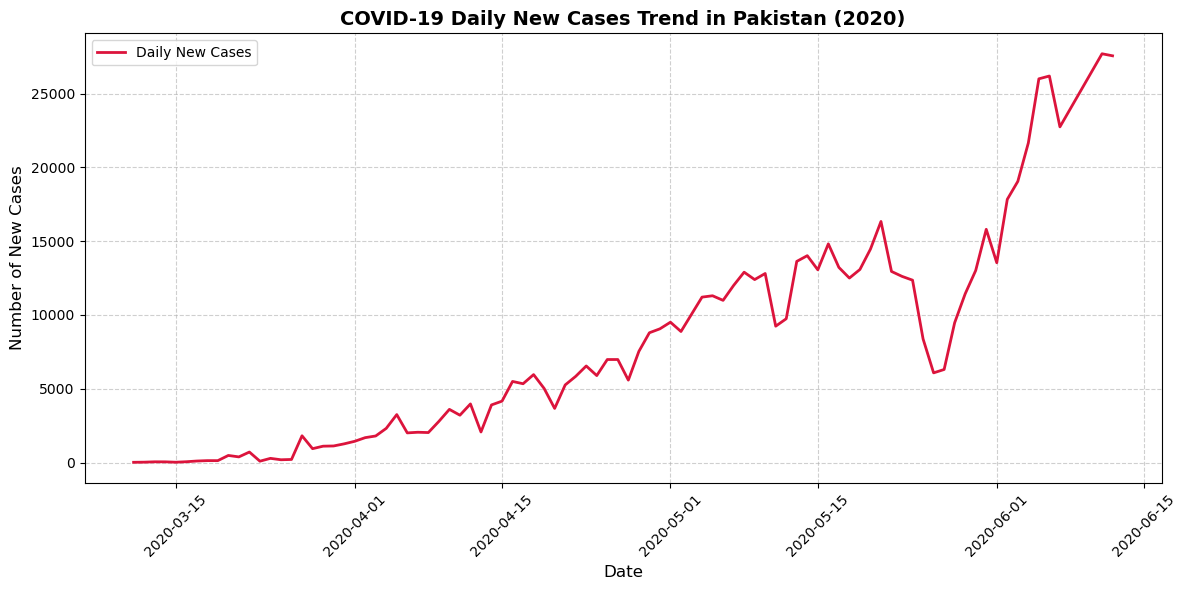

In [70]:
daily_trend = df.groupby('Date')['New_Cases'].sum()
plt.figure(figsize=(12, 6))
plt.plot(daily_trend.index, daily_trend.values, color='crimson', linewidth=2, label='Daily New Cases')
plt.title('COVID-19 Daily New Cases Trend in Pakistan (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of New Cases', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

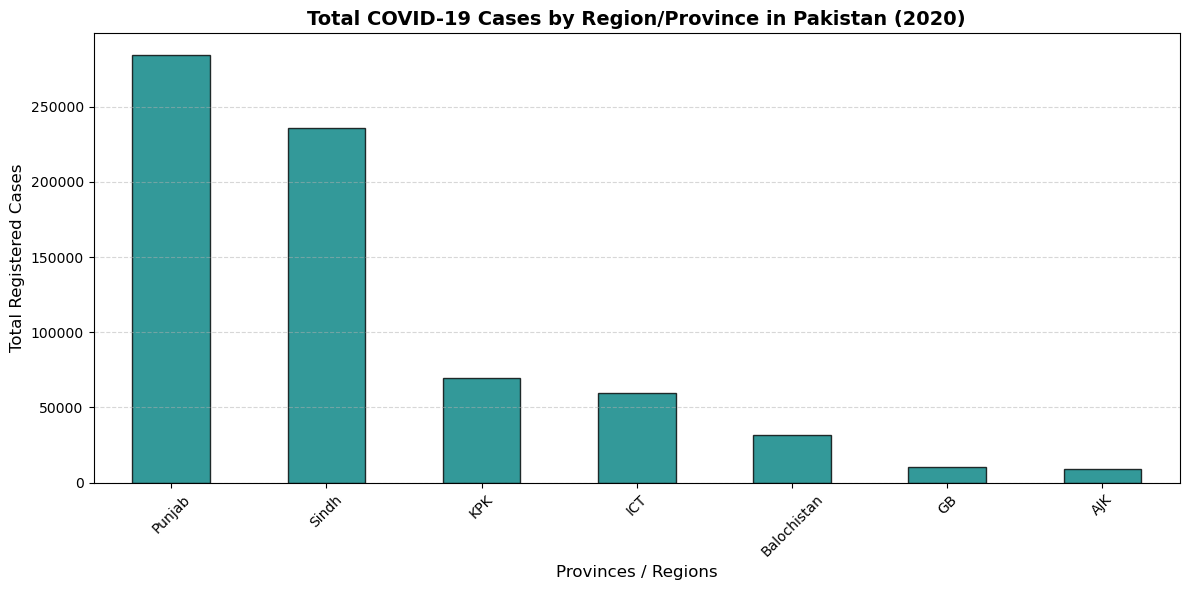

In [71]:
region_data = df.groupby('Region')['New_Cases'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
region_data.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)
plt.title('Total COVID-19 Cases by Region/Province in Pakistan (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Provinces / Regions', fontsize=12)
plt.ylabel('Total Registered Cases', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

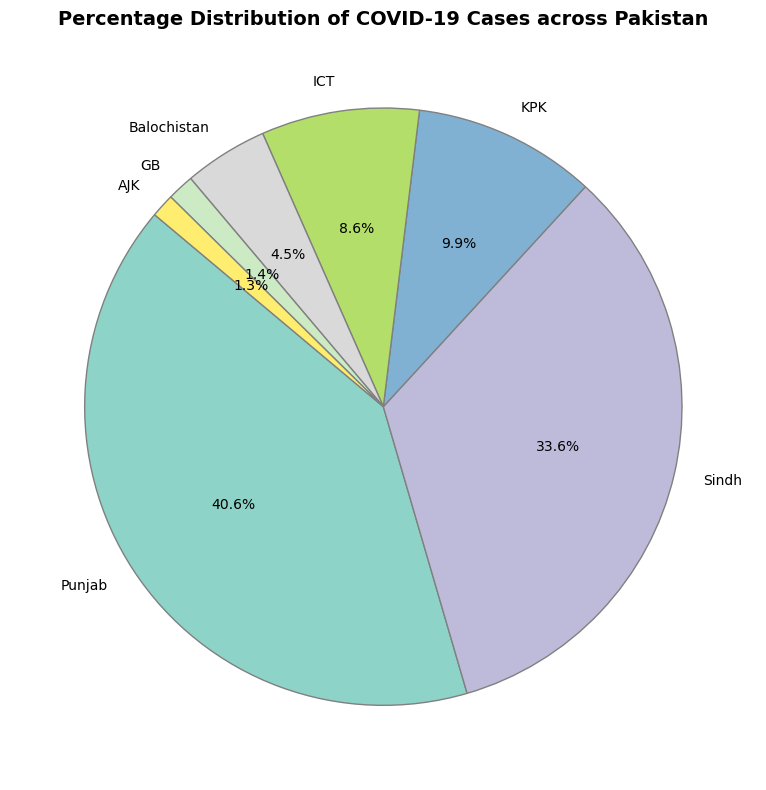

In [72]:
plt.figure(figsize=(8, 8))
region_data.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='Set3', wedgeprops={'edgecolor': 'gray'})
plt.title('Percentage Distribution of COVID-19 Cases across Pakistan', fontsize=14, fontweight='bold')
plt.ylabel('') 
plt.tight_layout()
plt.show()